# Pretrain sequence encoder for K562

In this tutorial, we will train a sequence encoder to predict chromatin accessibility for K562 cells. This is similar to ChromBPNet and the idea is to learn sequence variation across the whole genome.

## Overview

The goal of this tutorial is to demonstrate how to:
1. **Prepare multiome single-cell data** from K562 cells containing both RNA and ATAC-seq measurements
2. **Train a deep learning model** that learns to predict chromatin accessibility patterns from DNA sequences
3. **Use the pretrained encoder** as a foundation for downstream cell2net modeling tasks

## Background

K562 is a widely-studied human erythroleukemic cell line that serves as an important model system in genomics research. By training a sequence encoder on K562 data, we can:

- Learn fundamental sequence-to-accessibility relationships
- Create reusable representations for regulatory sequence analysis  
- Establish a baseline model for comparing cell-type-specific effects
- Leverage transfer learning for other cell types and conditions

## What you'll learn

- How to load and explore multiome single-cell data using MuData
- Data preprocessing steps for sequence encoder training
- Model architecture and training procedures for genomic sequence prediction
- Evaluation metrics and visualization of model performance
- How to save and reuse the pretrained encoder for downstream applications

Let's get started!

In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from scipy import stats
import os
import pandas as pd
import torch
import cell2net as cn
import mudata as md
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

md.set_options(pull_on_update=False)

### Load data

Let's first import the multiome single-cell data for K562 cells. 

In [8]:
mdata = md.read_h5mu(
    "../../../../results/37_K562_10x_multiome/05_create_mdata/mdata.h5mu"
)

In [9]:
mdata

MuData object with n_obs × n_vars = 6508 × 151699
  obs:	'total_counts_rna', 'total_counts_atac', 'total_counts_rna_log', 'total_counts_atac_log'
  2 modalities
    rna:	6508 x 15735
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'DoubletScore', 'DoubletEnrichment', 'ReadsInPeaks', 'FRIP', 'nCount_ATAC', 'nFeature_ATAC', 'percent.mt', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
      var:	'genes', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns:	'hvg'
      obsm:	'X_pca', 'X_umap'
      layers:	'counts'
    atac:	6508 x 135964
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'DoubletScore', 'DoubletEnrichment', 'ReadsInPeaks', 'FRIP', 'nCount_ATAC', 'nFeature_ATAC', 'percent.mt', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
      var:	'peaks', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      obsm:	'X_umap'
      layers:	'counts'

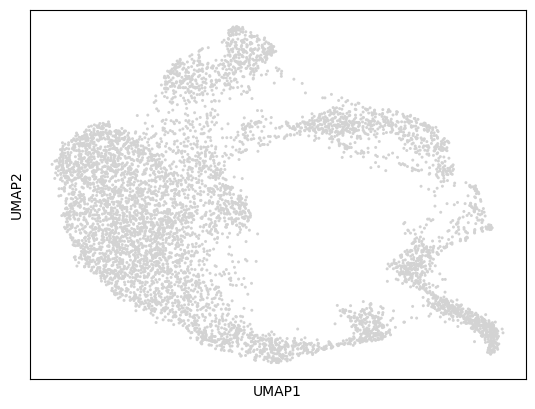

In [10]:
sc.pl.umap(mdata["rna"])

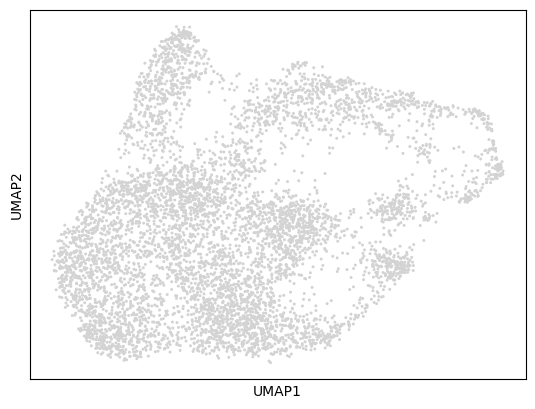

In [11]:
sc.pl.umap(mdata["atac"])

In [13]:
cn.pp.add_peaks(mdata, mod_name='atac', peak_len=256)
cn.pp.add_dna_sequence(mdata, ref_fasta='../../../../data/refdata-gex-GRCh38-2020-A/fasta/genome.fa')

Fetching sequences:  32%|███▏      | 43175/135964 [00:01<00:02, 33342.12it/s] 

Fetching sequences: 100%|██████████| 135964/135964 [00:16<00:00, 8034.74it/s]



In [ ]:
df_seq = mdata['atac'].uns['peaks']
df_true = mdata['atac'].layers['counts'].todense().sum(axis=0)
df_seq['acc'] = np.array(df_true).flatten()
df_seq['acc'] = np.log1p(df_seq['acc'])

In [ ]:
df_seq.head()

In [ ]:
# split data into training and validation sets by chromosome
chromosomes = df_seq['chr'].unique().tolist()
np.random.seed(42)
np.random.shuffle(chromosomes)
split_idx = int(len(chromosomes) * 0.8)
train_chromosomes = chromosomes[:split_idx]
valid_chromosomes = chromosomes[split_idx:]

df_train = df_seq[df_seq['chr'].isin(train_chromosomes)]
df_valid = df_seq[df_seq['chr'].isin(valid_chromosomes)]

In [ ]:
df_train = df_train[['sequence', 'acc']].reset_index(drop=True)
df_valid = df_valid[['sequence', 'acc']].reset_index(drop=True)

In [ ]:
sns.histplot(df_train['acc'], bins=100)

In [ ]:
sns.histplot(df_valid['acc'], bins=100)

In [ ]:
model = cn.pd.model.Seq2Acc(peak_len=256, dropout_rate=0.25)

In [ ]:
model.train(df_train=df_train, df_valid=df_valid, max_epochs=100, 
            batch_size=512, weight_decay=1e-04, lr=3e-04)

In [ ]:
model.save_module('./pretrained_seq2acc.pth')

In [ ]:
# load best model weights
pretrained_state_dict = torch.load('./pretrained_seq2acc.pth')
model.module.seq_encoder.load_state_dict(pretrained_state_dict)

In [ ]:
df_train['pred_acc'] = model.predict(df_train)
df_valid['pred_acc'] = model.predict(df_valid)

In [ ]:
pearsonR, pv = stats.pearsonr(df_train['acc'], df_train['pred_acc'])

ax = sns.jointplot(
    data=df_train,
    x="acc",
    y="pred_acc",
    kind = 'scatter',
    joint_kws={'marker':'o', 's':10, 'alpha':0.1, 'linewidth':0},
    marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
)
ax.plot_joint(sns.regplot, color="r", scatter=False, 
              line_kws={"color": "orange", 'linestyle':'dashed'})
_min = np.min((np.min(df_train['acc'].values), np.min(df_train['pred_acc'].values)))
_max = np.max((np.max(df_train['acc'].values), np.max(df_train['pred_acc'].values)))

# set axis-x and axis-y the same scale
plt.xlim(_min, _max)
plt.ylim(_min, _max)
plt.title('pearsonR = {:.3f}'.format(pearsonR))
plt.xlabel('True Accessibility (log1p counts)')
plt.ylabel('Predicted Accessibility (log1p counts)')
plt.tight_layout()

In [ ]:
pearsonR, pv = stats.pearsonr(df_valid['acc'], df_valid['pred_acc'])

ax = sns.jointplot(
    data=df_valid,
    x="acc",
    y="pred_acc",
    kind = 'scatter',
    joint_kws={'marker':'o', 's':10, 'alpha':0.1, 'linewidth':0},
    marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
)
ax.plot_joint(sns.regplot, color="r", scatter=False, 
              line_kws={"color": "orange", 'linestyle':'dashed'})

_min = np.min((np.min(df_valid['acc'].values), np.min(df_valid['pred_acc'].values)))
_max = np.max((np.max(df_valid['acc'].values), np.max(df_valid['pred_acc'].values)))

# set axis-x and axis-y the same scale
plt.xlim(_min, _max)
plt.ylim(_min, _max)
plt.title('pearsonR = {:.3f}'.format(pearsonR))
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('True Accessibility (log1p counts)')
plt.ylabel('Predicted Accessibility (log1p counts)')
plt.tight_layout()